![](https://img.shields.io/badge/PO.DAAC-Contribution-%20?color=grey&labelColor=blue)

> From the PO.DAAC Cookbook, to access the GitHub version of the notebook, follow [this link](https://github.com/podaac/tutorials/blob/master/notebooks/datasets/Hydrocron_SWOT_timeseries_examples_basic.ipynb).

_Note: This notebook uses the default SWOT RiverSP collection available through Hydrocron. At the time of writing, the default collection corresponds to Version D SWOT data._

# Hydrocron API: Getting Started with SWOT Time Series

#### Authors: Brandi Downs, Nikki Tebaldi, and Cassandra Nickles; NASA PO.DAAC

Last Updated: October 2026

### Summary:

[Hydrocron](https://podaac.github.io/hydrocron/) is an API that repackages the `SWOT_L2_HR_RiverSP_D` dataset into CSV or GeoJSON formats that make time series analysis easier. This notebook will highlight how to utilize Hydrocron and convert its output into a readable dataframe from multiple SWOT reaches identified from the [SWORD Database](https://www.swordexplorer.com/).

### Requirements:
Any compute environment, local or the cloud.

### Learning Objectives:
- Obtain a list of SWORD IDs for a river/region of interest
- Access SWOT river vector product attributes for multiple reach IDs via the Hydrocron API
- Convert accessed time series data into readable dataframe
- Plot one time series variable (e.g.  water surface elevation) for multiple reaches
- Access and plot SWOT L4 river discharge (v3) estimates from the [SWOT_L4_HR_DAWG_SOS_DISCHARGE_V3](https://www.earthdata.nasa.gov/data/catalog/pocloud-swot-l4-hr-dawg-sos-discharge-v3-3) data product alongside L2 water surface elevation, with a single Hydrocron query

### Cite the Hydrocron API via the following:

> Frank Greguska, Nikki Tebaldi, Victoria McDonald, Vanesa Gomez Gonzalez, & Cassie Nickles. (2024). podaac/hydrocron: 1.2.0 (1.2.0). Zenodo. https://doi.org/10.5281/zenodo.11176234

## Import Packages

In [1]:
import pandas as pd
import requests
import time
import folium
import hvplot.pandas
import holoviews as hv
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

## Obtain SWORD Reach IDs

In this section, we identify a list of river reach IDs from the SWOT River Database [(SWORD)](https://www.swordexplorer.com/). A river reach ID has the format `CBBBBBRRRRT`, while a node ID has the format, `CBBBBBRRRRNNNT`, where `C` stands for continent, `B` for basin, `R` for reach, `N` for node, and `T` for type. The first six digits of the id (CBBBBB) are the [HydroBASINS](https://www.hydrosheds.org/products/hydrobasins) Pfafstetter level 6 basin code, where the first digit represents one of nine continental regions (1 = Africa, 2 = Europe, 3 = Siberia, 4 = Asia, 5 = Oceania, 6 = South America, 7 = North America, 8 = Arctic, 9 = Greenland), and the remaining digits are nested basin levels 2–6.

In this example, we will use river reach IDs for two use cases:
1) for the Skagit River in Washington (in December 2025, major flooding occurred in western Washington driven by mountain rainfall in early December and a widespread precipitation event on December 8-11)
2) for the Mississippi River in Louisiana, exploring discharge and water surface elevation.

To identify the river reach IDs for Skagit River and Mississippi River, go to [SWORD](https://www.swordexplorer.com/), select the 'North America' tab, and select the basin that covers Washington State (basin 78) and LA, respecitvely (basin 74). After a few moments, the individual river reaches will load on the map, as shown in the screenshot below. Zoom in to the Skagit River in northern Washington, click on the individual reaches, and note the reach IDs. Repeat for Mississippi River. 

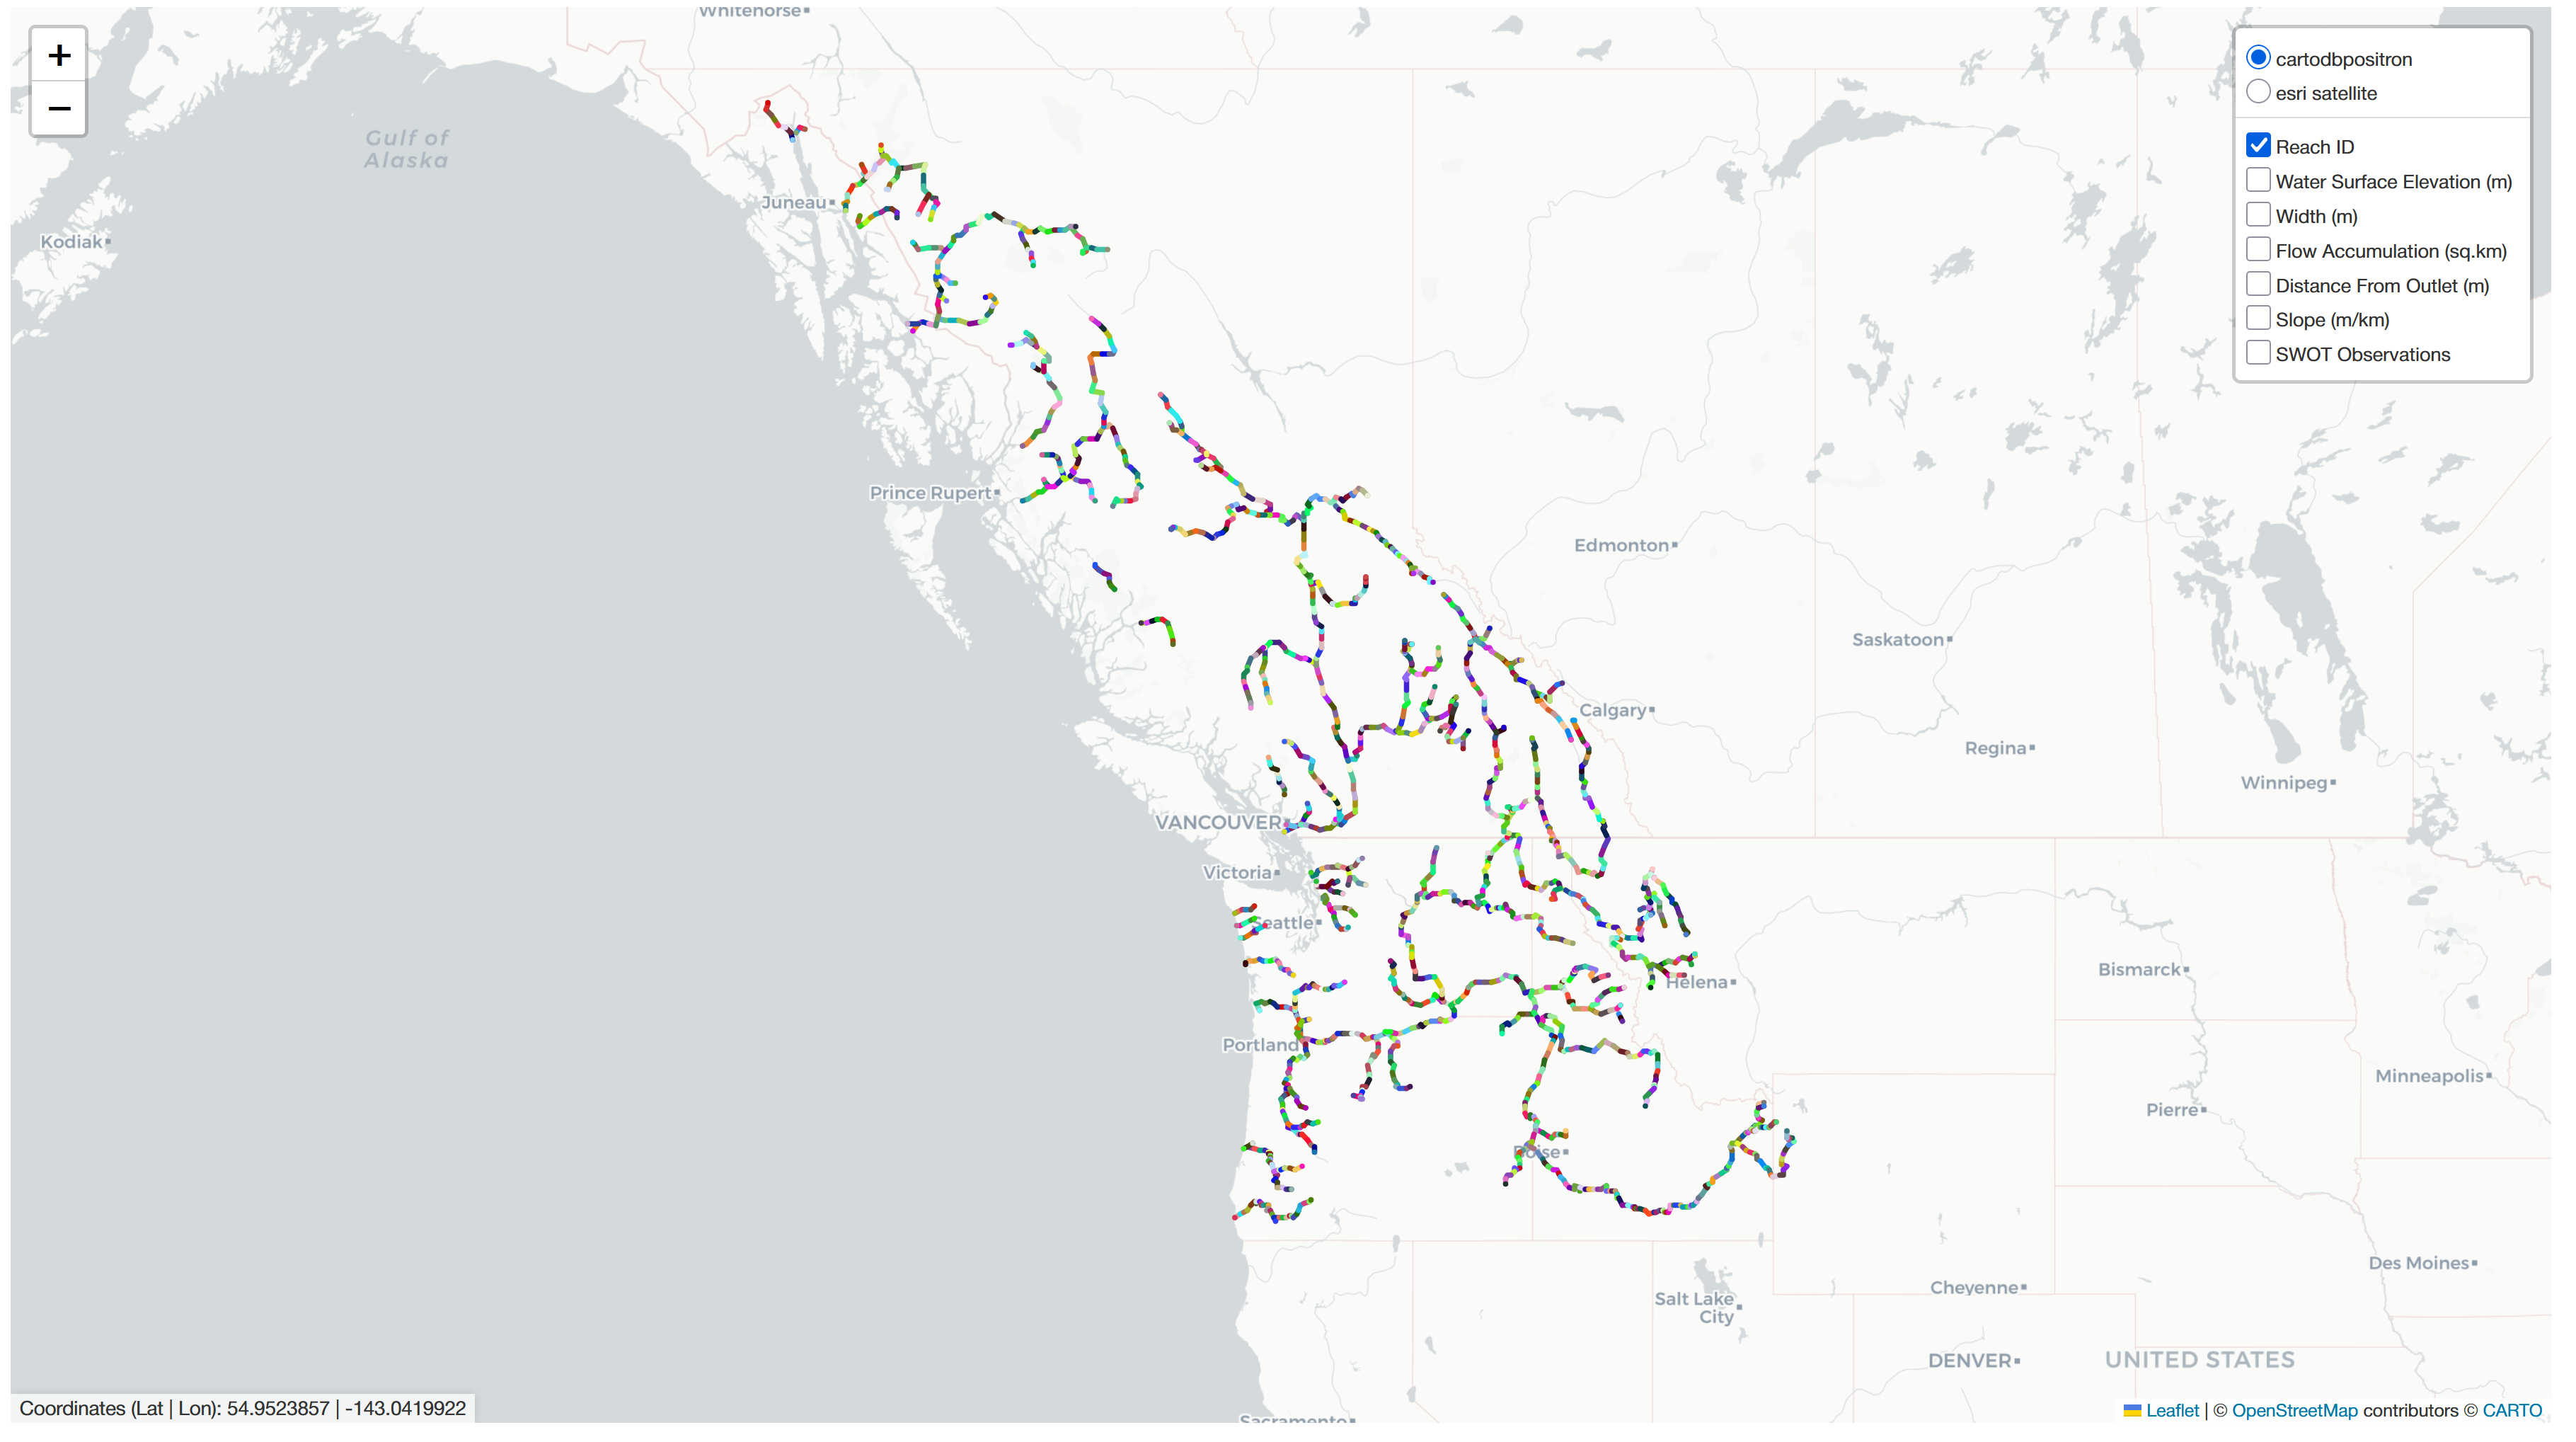

In [2]:
# Define the reach IDs and the Hydrocron URL

# Reach IDs for Skagit River in Washington, US
reach_ids = ['78310800191','78310800181','78310800171','78310800161','78310800081','78310800071',
             '78310800061','78310800051','78310800041','78310800031','78310800021','78310800015']

HYDROCRON_URL = "https://soto.podaac.earthdatacloud.nasa.gov/hydrocron/v1/timeseries"

## Query Hydrocron for Time Series Data

Depending on how many reaches you are querying for, this section could take between seconds to minutes.

All parameter options are listed in the Hydrocron documentation: [https://podaac.github.io/hydrocron/timeseries/](https://podaac.github.io/hydrocron/timeseries/)

Information about the fields (attributes that are available in the SWOT river shapefiles) can be found here: [https://podaac.github.io/hydrocron/user-guide/fields/](https://podaac.github.io/hydrocron/user-guide/fields/)

In [3]:
# Define a start and end time for retrieving SWOT RiverSP data
start_time = "2025-10-01T00:00:00Z"
end_time = "2026-01-31T00:00:00Z"

# Define the fields you want to retrieve
fields = "reach_id,time_str,wse,wse_u"


def query_hydrocron(
    query_url,
    reach_id,
    start_time,
    end_time,
    fields,
    collection_name=None
):
    """Query Hydrocron for reach-level time series data and geometry."""

    params = {
        "feature": "Reach",
        "feature_id": reach_id,
        "output": "geojson",
        "start_time": start_time,
        "end_time": end_time,
        "fields": fields
    }

    if collection_name is not None:
        params["collection_name"] = collection_name

    response = requests.get(query_url, params=params)
    response.raise_for_status()
    response = response.json()

    if "results" in response:
        geojson_data = response["results"]["geojson"]
        rows = [
            feature["properties"]
            for feature in geojson_data["features"]
        ]
        df = pd.DataFrame(rows)
    else:
        print(f"No results for reach {reach_id}: {response}")
        geojson_data = None
        df = pd.DataFrame()

    return df, geojson_data


t0 = time.perf_counter()

results = []
geojson_results = {}

for reach in reach_ids:

    df_reach, geojson_data = query_hydrocron(
        HYDROCRON_URL,
        reach,
        start_time,
        end_time,
        fields
    )

    if not df_reach.empty:
        results.append(df_reach)

    if geojson_data is not None:
        geojson_results[reach] = geojson_data
        
if results:
    df = pd.concat(results, ignore_index=True)
    
    # Convert numeric fields, replacing values that cannot be converted with NaN
    df["wse"] = pd.to_numeric(df["wse"], errors="coerce")
    df["wse_u"] = pd.to_numeric(df["wse_u"], errors="coerce")           
    df["time_str"] = pd.to_datetime(df["time_str"], errors="coerce")    
    df = df.dropna(subset=["time_str"])
else:
    df = pd.DataFrame()

print(f"Query time: {time.perf_counter()-t0}")

display(df)

Query time: 9.41286569996737


,reach_id,time_str,wse,wse_u,wse_units,wse_u_units
1,78310800191,2025-10-09 18:44:58+00:00,132.3752,0.09629,m,m
2,78310800191,2025-10-13 08:06:53+00:00,132.4446,0.09850,m,m
3,78310800191,2025-10-20 17:07:51+00:00,132.1659,0.17033,m,m
5,78310800191,2025-10-30 15:30:05+00:00,132.5509,0.09756,m,m
6,78310800191,2025-11-03 04:51:59+00:00,132.7871,0.10375,m,m
...,...,...,...,...,...,...
235,78310800015,2025-12-25 20:44:51+00:00,2.1087,0.09587,m,m
236,78310800015,2026-01-02 05:45:57+00:00,1.3743,0.25852,m,m
237,78310800015,2026-01-12 04:08:09+00:00,1.3693,0.09339,m,m
238,78310800015,2026-01-15 17:29:55+00:00,2.2662,0.09627,m,m


Note: Interactive Folium maps and hvPlot visualizations may not render in GitHub's notebook preview.</br>
Run the notebook locally in JupyterLab to view these outputs.

In [4]:
# Map the river reaches

if not geojson_results:
    raise ValueError("No GeoJSON results were returned. Cannot create map.")
    
# Generate colors for each reach
cmap = plt.colormaps.get_cmap("tab20").resampled(len(geojson_results))
colors = [
    mcolors.to_hex(cmap(i))
    for i in range(len(geojson_results))
]
color_dict = dict(zip(geojson_results.keys(), colors))

reach_map = folium.Map(tiles="OpenStreetMap")

for reach_id, geojson_data in geojson_results.items():

    folium.GeoJson(
        geojson_data,
        name=f"Reach ID {reach_id}",
        style_function=lambda feature, reach_id=reach_id: {
            "color": color_dict[reach_id],
            "weight": 4
        },

        tooltip=folium.GeoJsonTooltip(
            fields=["reach_id"],
            aliases=["Reach ID:"]
        )

    ).add_to(reach_map)

folium.LayerControl().add_to(reach_map)

reach_map.fit_bounds(reach_map.get_bounds(), padding=(30, 30))

reach_map

In hvPlot, the asterisk (`*`) operator is used to overlay objects on the same axis. Here, we use this operator to combine multiple individual line and scatter plots into a single visual.

In [5]:
# Plot the time series results

# Remove fill values
df_plot = df[df["wse"] > -9999].copy()

line_plots = []
scatter_plots = []

for reach_id in reach_ids:

    df_reach = df_plot[df_plot["reach_id"].astype(str) == str(reach_id)]

    color = color_dict[reach_id]

    line = df_reach.hvplot(
        x="time_str",
        y="wse",
        kind="line",
        color=color,
        label=f"Reach ID {reach_id}"
    ).opts(tools=[])  # tools=[] removes tooltips from the line segments

    scatter = df_reach.hvplot(
        x="time_str",
        y="wse",
        kind="scatter",
        color=color,
        hover_cols=["reach_id"]
    )

    line_plots.append(line)
    scatter_plots.append(scatter)

# Build up one large overlay plot from individual line and scatter plots
if not line_plots:
    raise ValueError("No valid data available to plot.")
plot = line_plots[0]
for p in line_plots[1:]:
    plot *= p
for p in scatter_plots:
    plot *= p

plot.opts(
    width=1100,
    height=500,
    xlabel="Date",
    ylabel="Water Surface Elevation (m)",
    title="WSE by Reach ID and Observation Date",
    xrotation=90,
    legend_position="right",
    show_grid=True
)

:Overlay
   .Curve.Reach_ID_78310800191 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800181 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800171 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800161 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800081 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800071 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800061 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800051 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800041 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800031 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800021 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800015 :Curve   [time_str]   (wse)
   .Scatter.I                  :Scatter   [time_str]   (wse,reach_id)
   .Scatter.II                 :Scatter   [time_str]   (wse,reach_id)
   .Scatter.III                :Scatter   [time_str]   (wse,reach_id)
   .Scatter.IV                 :Scatter   [time_str]   (wse,reach_id)
   .Scatter.V                  :Scatter   [time_str]   (wse,reach_id)
   .Scatter.VI                 :Scatter   [time_str]   (wse,reach_id)
   .Scatter.VII                :Scatter   [time_str]   (wse,reach_id)
   .Scatter.VIII               :Scatter   [time_str]   (wse,reach_id)
   .Scatter.IX                 :Scatter   [time_str]   (wse,reach_id)
   .Scatter.X                  :Scatter   [time_str]   (wse,reach_id)
   .Scatter.XI                 :Scatter   [time_str]   (wse,reach_id)
   .Scatter.XII                :Scatter   [time_str]   (wse,reach_id)

The plotted results show an increase in water surface elevation on December 11, 2025 for the reach IDs with measurements on that date, coinciding with the time period of flooding.

However, for reach IDs `78310800031` and `78310800021`, there appear to be some anomalous data points, in particular for 2025-12-04 and 2026-01-02. We can investigate these data points further using the water surface elevation uncertainty (`wse_u`) parameter. `wse_u` is the total uncertainty (random and systematic) in the reach WSE and has units of meters. High `wse_u` values are not automatically invalid, but they can help identify measurements that may be less reliable and worth reviewing before interpretation.

In [6]:
# Plot the water surface elevation uncertainty

# Remove fill values
df_plot = df[
    (df["wse"] > -9999) &
    (df["wse_u"] > -9999)
].copy()

scatter_plots = []

for reach_id in reach_ids:

    df_reach = df_plot[df_plot["reach_id"].astype(str) == str(reach_id)]

    scatter = df_reach.hvplot(
        x="time_str",
        y="wse_u",
        kind="scatter",
        color=color_dict[reach_id],
        label=f"Reach ID {reach_id}",
        hover_cols=["reach_id"]
    )

    scatter_plots.append(scatter)

# Build up one large overlay plot from individual scatter plots
if not scatter_plots:
    raise ValueError("No valid uncertainty data available to plot.")
plot = scatter_plots[0]
for p in scatter_plots[1:]:
    plot *= p
    
# Add a horizontal line corresponding to an uncertainty level of 0.5 m
threshold = hv.HLine(0.5).opts(line_dash="dashed", color="gray")

# Place annotation above horizontal line
x_pos = df_plot["time_str"].min()
y_pos = 0.52
label = hv.Text(x_pos, y_pos, "0.5 m").opts(text_align="left", text_color="gray", text_font_size="10pt")

# Add horizontal line and annotation to the plot
plot = plot * threshold * label

plot.opts(
    width=1100,
    height=500,
    xlabel="Date",
    ylabel="WSE Uncertainty (m)",
    title="WSE Uncertainty per Measurement",
    xrotation=90,
    legend_position="right",
    yformatter="%.2f",
    yticks=5,
    ylim=(0,1.0),
    show_grid=True
)

:Overlay
   .Scatter.Reach_ID_78310800191 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800181 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800171 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800161 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800081 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800071 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800061 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800051 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800041 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800031 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800021 :Scatter   [time_str]   (wse_u,reach_id)
   .Scatter.Reach_ID_78310800015 :Scatter   [time_str]   (wse_u,reach_id)
   .HLine.I                      :HLine   [x,y]
   .Text.I                       :Text   [x,y]

Based on the uncertainty values shown above, we'll use 0.5 m as the maximum WSE uncertainty for this example.

In [7]:
# Plot the uncertainty-filtered time series results


# Set water surface elevation uncertainty threshold
WSE_U_THRESHOLD = 0.5


# Remove fill values and filter out data points with high uncertainty
df_plot = df[
    (df["wse"] > -9999) &
    (df["wse_u"] > -9999) &
    (df["wse_u"] <= WSE_U_THRESHOLD)
].copy()


line_plots = []
scatter_plots = []

for reach_id in reach_ids:

    df_reach = df_plot[df_plot["reach_id"].astype(str) == str(reach_id)]

    color = color_dict[reach_id]

    line = df_reach.hvplot(
        x="time_str",
        y="wse",
        kind="line",
        color=color,
        label=f"Reach ID {reach_id}"
    ).opts(tools=[])

    scatter = df_reach.hvplot(
        x="time_str",
        y="wse",
        kind="scatter",
        color=color,
        hover_cols=["wse_u","reach_id"]
    )

    line_plots.append(line)
    scatter_plots.append(scatter)

# Build up one large overlay plot from individual line and scatter plots
if not line_plots:
    raise ValueError("No valid data available to plot.")
plot = line_plots[0]
for p in line_plots[1:]:
    plot *= p
for p in scatter_plots:
    plot *= p

plot.opts(
    width=1100,
    height=500,
    xlabel="Date",
    ylabel="Water Surface Elevation (m)",
    title="WSE After Removing High Uncertainty Data Points",
    xrotation=90,
    legend_position="right",
    show_grid=True
)

:Overlay
   .Curve.Reach_ID_78310800191 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800181 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800171 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800161 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800081 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800071 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800061 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800051 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800041 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800031 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800021 :Curve   [time_str]   (wse)
   .Curve.Reach_ID_78310800015 :Curve   [time_str]   (wse)
   .Scatter.I                  :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.II                 :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.III                :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.IV                 :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.V                  :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.VI                 :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.VII                :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.VIII               :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.IX                 :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.X                  :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.XI                 :Scatter   [time_str]   (wse,wse_u,reach_id)
   .Scatter.XII                :Scatter   [time_str]   (wse,wse_u,reach_id)

## Query Hydrocron for Discharge Data

In addition to SWOT Level 2 river and lake observations, Hydrocron serves river discharge estimates from the [SWOT Level 4 Sword of Science (SoS) River Discharge Products, Version 3](https://www.earthdata.nasa.gov/data/catalog/pocloud-swot-l4-hr-dawg-sos-discharge-v3-3). At the time of this writing, these river discharge products are generated from SWOT L2 RiverSP vC (formerly known as v2.0). Therefore, to retrieve discharge data through Hydrocron, we must specify the `SWOT_L2_HR_RiverSP_2.0` collection using the `collection_name` parameter rather than the default vD collection.

Because RiverSP vC uses SWORD v16, the corresponding queries must also use SWORD v16 reach IDs. River reach and node IDs have changed in the current SWORD v17b release as a result of an overhauled topological network, so not all IDs in v17b exist in v16. Users should keep this in mind when identifying the reach IDs they wish to query for discharge data.

For this example, we will use reach ID `74210000201`, a section of the Mississippi River near Baton Rouge.

For more information about the river discharge data available through Hydrocron, see the [Hydrocron discharge documentation](https://podaac.github.io/hydrocron/user-guide/discharge/).

In [8]:
# Define the reach ID we'll use for the discharge retrieval

reach_id = "74210000201"

collection_name = "SWOT_L2_HR_RiverSP_2.0"
start_time = "2023-06-01T00:00:00Z"
end_time = "2025-06-01T00:00:00Z"
fields = "reach_id,time_str,wse,wse_u,sos_consensus_q,sos_hivdi_q,sos_metroman_q,sos_momma_q,sos_sad_q,sos_sic4dvar_q"

t0 = time.perf_counter()

# Query Hydrocron
df, geojson_data = query_hydrocron(
    HYDROCRON_URL,
    reach_id,
    start_time,
    end_time,
    fields,
    collection_name=collection_name
)

if not df.empty:
    # Convert numeric fields, replacing values that cannot be converted with NaN
    df["wse"] = pd.to_numeric(df["wse"], errors="coerce")
    df["wse_u"] = pd.to_numeric(df["wse_u"], errors="coerce")
    df["sos_consensus_q"] = pd.to_numeric(df["sos_consensus_q"], errors="coerce")
    df["sos_hivdi_q"] = pd.to_numeric(df["sos_hivdi_q"], errors="coerce")
    df["sos_metroman_q"] = pd.to_numeric(df["sos_metroman_q"], errors="coerce")
    df["sos_momma_q"] = pd.to_numeric(df["sos_momma_q"], errors="coerce")
    df["sos_sad_q"] = pd.to_numeric(df["sos_sad_q"], errors="coerce")
    df["sos_sic4dvar_q"] = pd.to_numeric(df["sos_sic4dvar_q"], errors="coerce")

    # Convert time to datetime and remove invalid times
    df["time_str"] = pd.to_datetime(df["time_str"], errors="coerce")
    df = df.dropna(subset=["time_str"])

print(f"Query time: {time.perf_counter() - t0:.2f} seconds")

display(df)

Query time: 1.47 seconds


,reach_id,time_str,wse,wse_u,sos_consensus_q,sos_hivdi_q,sos_metroman_q,sos_momma_q,sos_sad_q,sos_sic4dvar_q,wse_units,wse_u_units,sos_consensus_q_units,sos_hivdi_q_units,sos_metroman_q_units,sos_momma_q_units,sos_sad_q_units,sos_sic4dvar_q_units
0,74210000201,2023-07-29 22:11:58+00:00,2.9386,0.09229,9.135624e+03,-1.000000e+12,7.006242e+03,1.126500e+04,-1.000000e+12,7.606596e+03,m,m,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s
1,74210000201,2023-08-08 09:43:20+00:00,1.7565,0.09339,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,m,m,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s
2,74210000201,2023-08-29 06:28:25+00:00,2.8492,0.09131,9.371853e+03,-1.000000e+12,6.838808e+03,1.190490e+04,-1.000000e+12,7.496017e+03,m,m,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s
3,74210000201,2023-08-30 17:19:52+00:00,2.4935,0.10075,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,6.910086e+03,m,m,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s
4,74210000201,2023-09-09 15:42:10+00:00,1.7902,0.09206,6.997124e+03,-1.000000e+12,5.471253e+03,8.522996e+03,-1.000000e+12,6.188502e+03,m,m,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,74210000201,2025-03-25 23:59:16+00:00,7.4750,0.09449,1.499421e+04,-1.000000e+12,1.428655e+04,1.570187e+04,-1.000000e+12,1.436388e+04,m,m,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s
78,74210000201,2025-04-04 11:30:36+00:00,6.5812,0.09559,1.267056e+04,-1.000000e+12,1.251056e+04,1.283056e+04,-1.000000e+12,1.290313e+04,m,m,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s
79,74210000201,2025-04-05 22:22:03+00:00,6.2787,0.09769,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,1.236548e+04,m,m,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s
80,74210000201,2025-04-15 20:44:21+00:00,10.1833,0.09396,1.887300e+04,-1.000000e+12,1.943319e+04,1.831282e+04,-1.000000e+12,1.891850e+04,m,m,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s,m^3/s


In [9]:
# Map the river reach

if geojson_data is None:
    raise ValueError("No GeoJSON result was returned. Cannot create map.")

reach_map = folium.Map(tiles="OpenStreetMap")

folium.GeoJson(
    geojson_data,
    name=f"Reach ID {reach_id}",
    style_function=lambda feature: {
        "color": "#1f77b4",
        "weight": 4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["reach_id"],
        aliases=["Reach ID:"]
    )
).add_to(reach_map)

reach_map.fit_bounds(reach_map.get_bounds(), padding=(30, 30))

reach_map

In [10]:
# Plot discharge and water surface elevation for a single reach

# Choose discharge variable to plot
discharge_var = "sos_consensus_q"

# Select the reach to plot
df_plot = df.loc[df['reach_id'] == reach_id].copy()

# Replace fill values with NaN
df_plot.loc[df_plot[discharge_var] < -1e10, discharge_var] = np.nan
df_plot.loc[df_plot["wse"] < -1e10, "wse"] = np.nan

# Remove rows without a valid time or discharge data point
df_plot = df_plot.dropna(subset=["time_str"])


# WSE line
wse_line = df_plot.hvplot(
    x="time_str",
    y="wse",
    kind="line",
    color="lightsteelblue",
    line_dash="dashed",
    label="WSE"
).opts(
    ylabel="Water Surface Elevation (m)",
    tools=[]
)


# WSE points
wse_scatter = df_plot.hvplot(
    x="time_str",
    y="wse",
    kind="scatter",
    color="lightsteelblue",
    hover_cols=["wse", "reach_id"]
)


# Discharge line
discharge_line = df_plot.hvplot(
    x="time_str",
    y=discharge_var,
    kind="line",
    color="#1f77b4",
    label="Discharge"
).opts(
    ylabel="Discharge (m^3/s)",
    tools=[]
)


# Discharge points
discharge_scatter = df_plot.hvplot(
    x="time_str",
    y=discharge_var,
    kind="scatter",
    color="#1f77b4",
    hover_cols=[discharge_var, "reach_id"]
)


# Overlay all plots
plot = (
    wse_line *
    wse_scatter *
    discharge_line *
    discharge_scatter
)

plot.opts(
    multi_y=True,
    width=1100,
    height=500,
    xlabel="Date",
    title=f"River Discharge and WSE for Reach ID: {reach_id}",
    legend_position="right",
    show_grid=True
)

:Overlay
   .Curve.WSE       :Curve   [time_str]   (wse)
   .Scatter.I       :Scatter   [time_str]   (wse,reach_id)
   .Curve.Discharge :Curve   [time_str]   (sos_consensus_q)
   .Scatter.II      :Scatter   [time_str]   (sos_consensus_q,reach_id)

Notice that discharge estimates are not available for every observation. Anomalies in the observed data, such as WSE, width, slope, and other SWOT observations, can trigger quality control flags that identify a measurement as unreliable. These quality checks are also used to determine whether a discharge estimate is produced. For example, the anomalous WSE measurement shown in the plot above does not have an associated discharge estimate likely because it failed the discharge quality-control criteria. In some cases, WSE may appear reasonable but discharge is still not produced because other quality-control criteria have flagged the observation as unreliable.

Next, we'll remove all data points without a discharge estimate and plot only observations for which discharge estimates are available.

In [11]:
# Plot discharge and water surface elevation for a single reach

# Choose discharge variable to plot
discharge_var = "sos_consensus_q"

# Select the reach to plot
df_plot = df.loc[df['reach_id'] == reach_id].copy()

# Replace fill values with NaN
df_plot.loc[df_plot[discharge_var] < -1e10, discharge_var] = np.nan
df_plot.loc[df_plot["wse"] < -1e10, "wse"] = np.nan

# Remove rows without a valid time or discharge data point
df_plot = df_plot.dropna(subset=["time_str","wse",discharge_var])


# WSE line
wse_line = df_plot.hvplot(
    x="time_str",
    y="wse",
    kind="line",
    color="lightsteelblue",
    line_dash="dashed",
    label="WSE"
).opts(
    ylabel="Water Surface Elevation (m)",
    tools=[]
)


# WSE points
wse_scatter = df_plot.hvplot(
    x="time_str",
    y="wse",
    kind="scatter",
    color="lightsteelblue",
    hover_cols=["wse", "reach_id"]
)


# Discharge line
discharge_line = df_plot.hvplot(
    x="time_str",
    y=discharge_var,
    kind="line",
    color="#1f77b4",
    label="Discharge"
).opts(
    ylabel="Discharge (m^3/s)",
    tools=[]
)


# Discharge points
discharge_scatter = df_plot.hvplot(
    x="time_str",
    y=discharge_var,
    kind="scatter",
    color="#1f77b4",
    hover_cols=[discharge_var, "reach_id"]
)


# Overlay all plots
plot = (
    wse_line *
    wse_scatter *
    discharge_line *
    discharge_scatter
)

plot.opts(
    multi_y=True,
    width=1100,
    height=500,
    xlabel="Date",
    title=f"River Discharge and WSE for Reach ID: {reach_id}",
    legend_position="right",
    show_grid=True
)

:Overlay
   .Curve.WSE       :Curve   [time_str]   (wse)
   .Scatter.I       :Scatter   [time_str]   (wse,reach_id)
   .Curve.Discharge :Curve   [time_str]   (sos_consensus_q)
   .Scatter.II      :Scatter   [time_str]   (sos_consensus_q,reach_id)

## Summary

In this notebook, we used Hydrocron to retrieve and visualize SWOT river time series data. We identified SWORD reach IDs, queried Hydrocron for water surface elevation and uncertainty data, examined measurement uncertainty, and filtered observations based on an example uncertainty threshold. We also retrieved SWOT river discharge estimates alongside WSE observations with a single Hydrocron request for the reach ID of interest, and explored how quality control can affect the availability of discharge estimates.

Hydrocron provides a convenient way to access SWOT river observations as time series without having to download, manage and manipulate the original RiverSP product files (shp). For additional parameters, output options, and examples, see the [Hydrocron documentation](https://podaac.github.io/hydrocron/).